# EDA — All-Atom (AA) y United-Atom (UA)
Análisis Exploratorio de Datos para los datasets de descriptores atómicos.

**Inputs:** `dataset_AA.csv` y `dataset_UA.csv` generados por `extract_dataset_v3.py` + `split_v2.py`


## 0. Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"]  = 11

# ── Rutas ─────────────────────────────────────────────────────────────────────
PATH_AA = "dataset_AA.csv"
PATH_UA = "dataset_UA.csv"

# ── Columnas ──────────────────────────────────────────────────────────────────
ID_COLS     = ["molecule", "atom_id", "atom_name"]
TARGET_COLS = ["atomtype", "charge"]
CAT_COLS    = ["tripos_type", "element", "neighbor_config", "neighbor2_config"]
BOOL_COLS   = ["is_planar", "is_in_ring", "is_aromatic"]
NUM_COLS_ALL = [
    "mass", "coordination", "n_dihedrals",
    "avg_bond_len_A", "avg_angle_deg",
    "C_count", "H_count", "O_count", "N_count",
    "n_electroneg_neighbors", "n_electroneg_neighbors2",
    "bonds_single", "bonds_double", "bonds_aromatic",
    "ring_size", "formal_charge", "degree_of_unsat", "gasteiger_charge",
]
RARE_THRESHOLD = 5   # atomtypes con menos de N instancias → alerta

# ── Carga ─────────────────────────────────────────────────────────────────────
df_AA = pd.read_csv(PATH_AA)
df_UA = pd.read_csv(PATH_UA)

def num_cols(df):
    return [c for c in NUM_COLS_ALL if c in df.columns]

print(f"AA: {df_AA.shape[0]} átomos × {df_AA.shape[1]} columnas")
print(f"UA: {df_UA.shape[0]} átomos × {df_UA.shape[1]} columnas")

AA: 472 átomos × 31 columnas
UA: 315 átomos × 31 columnas


## 1. Overview general

In [2]:
for label, df in [("ALL-ATOM", df_AA), ("UNITED-ATOM", df_UA)]:
    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")
    print(f"  Átomos:           {len(df)}")
    print(f"  Moléculas únicas: {df['molecule'].nunique()}")
    print(f"  Clases atomtype:  {df['atomtype'].nunique()}")
    print(f"  Rango charge:     [{df['charge'].min():.3f}, {df['charge'].max():.3f}]")
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if nulls.empty:
        print("  Valores nulos:    ninguno ✓")
    else:
        print(f"  ⚠ Nulos:\n{nulls.to_string()}")


  ALL-ATOM
  Átomos:           472
  Moléculas únicas: 7
  Clases atomtype:  20
  Rango charge:     [-0.608, 0.820]
  Valores nulos:    ninguno ✓

  UNITED-ATOM
  Átomos:           315
  Moléculas únicas: 7
  Clases atomtype:  20
  Rango charge:     [-0.608, 0.820]
  Valores nulos:    ninguno ✓


## 2. Comparación AA vs UA
Qué átomos son exclusivos de cada tabla y cuáles son compartidos.


Atomtypes solo en AA (0):     []
Atomtypes solo en UA (0):     []
Atomtypes compartidos (20):     ['C', 'CAro', 'CH1', 'CH2', 'CH3', 'CL', 'CLAro', 'F', 'H', 'HC', 'HS14', 'N', 'NOpt', 'NPri', 'NT', 'O', 'OA', 'OE', 'OM', 'SDmso']


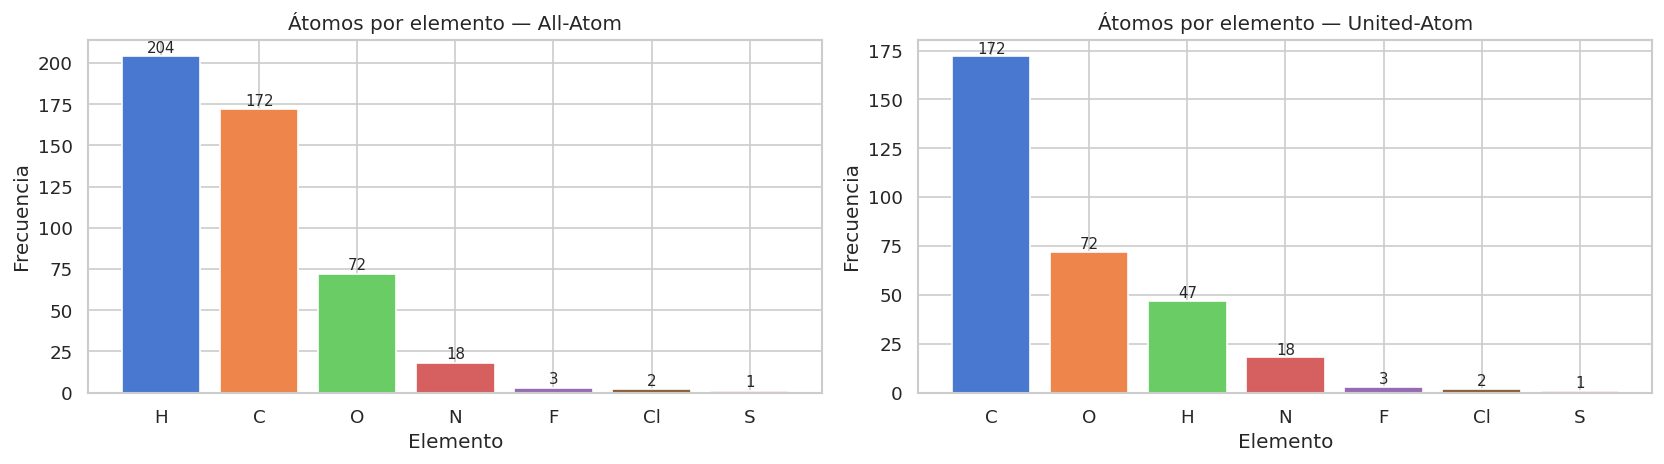

In [3]:
types_AA = set(df_AA["atomtype"].unique())
types_UA = set(df_UA["atomtype"].unique())

only_AA   = types_AA - types_UA
only_UA   = types_UA - types_AA
shared    = types_AA & types_UA

print(f"Atomtypes solo en AA ({len(only_AA)}):     {sorted(only_AA)}")
print(f"Atomtypes solo en UA ({len(only_UA)}):     {sorted(only_UA)}")
print(f"Atomtypes compartidos ({len(shared)}):     {sorted(shared)}")

# Conteo de átomos por elemento en cada tabla
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (label, df) in zip(axes, [("All-Atom", df_AA), ("United-Atom", df_UA)]):
    counts = df["element"].value_counts()
    colors = sns.color_palette("muted", len(counts))
    ax.bar(counts.index, counts.values, color=colors)
    ax.set_title(f"Átomos por elemento — {label}")
    ax.set_xlabel("Elemento")
    ax.set_ylabel("Frecuencia")
    for i, v in enumerate(counts.values):
        ax.text(i, v + len(df)*0.005, str(v), ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## 3. Distribución de clases de atomtype
Target de clasificación. Se analiza el desbalance entre clases.


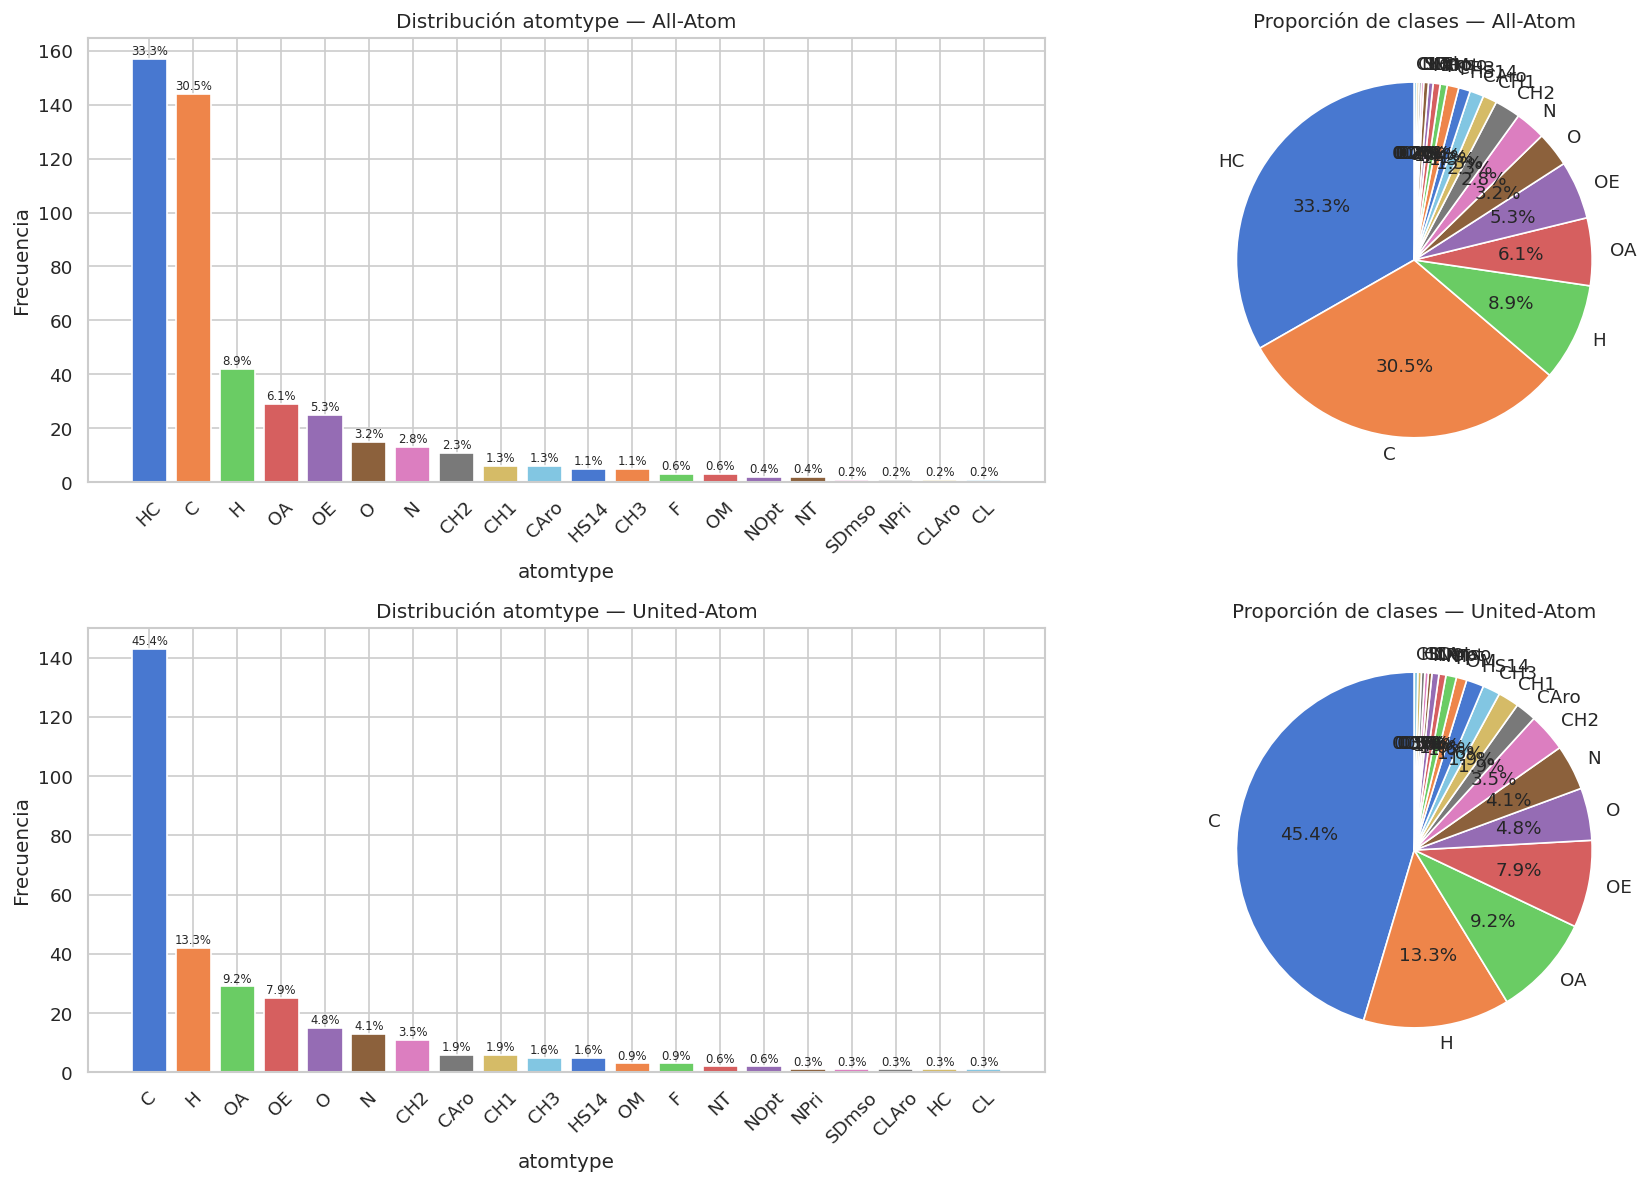


All-Atom:
  Clase más frecuente:   HC (157)
  Clase menos frecuente: SDmso (1)
  Ratio de desbalance:   157.0x
  ⚠ Desbalance severo — usar class_weight='balanced'.

United-Atom:
  Clase más frecuente:   C (143)
  Clase menos frecuente: NPri (1)
  Ratio de desbalance:   143.0x
  ⚠ Desbalance severo — usar class_weight='balanced'.


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for row, (label, df) in enumerate([("All-Atom", df_AA), ("United-Atom", df_UA)]):
    counts = df["atomtype"].value_counts()
    pct    = (counts / len(df) * 100).round(2)
    colors = sns.color_palette("muted", len(counts))

    # Barplot
    ax = axes[row][0]
    ax.bar(counts.index, counts.values, color=colors)
    ax.set_title(f"Distribución atomtype — {label}")
    ax.set_xlabel("atomtype")
    ax.set_ylabel("Frecuencia")
    ax.tick_params(axis="x", rotation=45)
    for i, (v, p) in enumerate(zip(counts.values, pct.values)):
        ax.text(i, v + counts.max()*0.01, f"{p:.1f}%", ha="center", fontsize=7)

    # Pie
    ax = axes[row][1]
    ax.pie(counts.values, labels=counts.index, autopct="%1.1f%%",
           colors=colors, startangle=90)
    ax.set_title(f"Proporción de clases — {label}")

plt.tight_layout()
plt.show()

for label, df in [("All-Atom", df_AA), ("United-Atom", df_UA)]:
    counts = df["atomtype"].value_counts()
    ratio  = counts.max() / counts.min()
    print(f"\n{label}:")
    print(f"  Clase más frecuente:   {counts.idxmax()} ({counts.max()})")
    print(f"  Clase menos frecuente: {counts.idxmin()} ({counts.min()})")
    print(f"  Ratio de desbalance:   {ratio:.1f}x")
    if ratio > 10:
        print("  ⚠ Desbalance severo — usar class_weight='balanced'.")
    elif ratio > 5:
        print("  ⚠ Desbalance moderado — considerar class_weight.")
    else:
        print("  ✓ Distribución razonablemente balanceada.")

## 4. Detección de clases raras
Atomtypes con muy pocas instancias que pueden generar problemas en clasificación.


In [5]:
for label, df in [("All-Atom", df_AA), ("United-Atom", df_UA)]:
    counts = df["atomtype"].value_counts()
    rare   = counts[counts < RARE_THRESHOLD]
    print(f"\n{label} — atomtypes con menos de {RARE_THRESHOLD} instancias:")
    if rare.empty:
        print("  ✓ Ninguna clase rara encontrada.")
    else:
        print(f"  ⚠ {len(rare)} clases raras:")
        for at, n in rare.items():
            print(f"    {at}: {n} instancia(s)")
        print("  → Considerar agrupar, eliminar o usar oversampling.")


All-Atom — atomtypes con menos de 5 instancias:
  ⚠ 8 clases raras:
    F: 3 instancia(s)
    OM: 3 instancia(s)
    NOpt: 2 instancia(s)
    NT: 2 instancia(s)
    SDmso: 1 instancia(s)
    NPri: 1 instancia(s)
    CLAro: 1 instancia(s)
    CL: 1 instancia(s)
  → Considerar agrupar, eliminar o usar oversampling.

United-Atom — atomtypes con menos de 5 instancias:
  ⚠ 9 clases raras:
    OM: 3 instancia(s)
    F: 3 instancia(s)
    NT: 2 instancia(s)
    NOpt: 2 instancia(s)
    NPri: 1 instancia(s)
    SDmso: 1 instancia(s)
    CLAro: 1 instancia(s)
    HC: 1 instancia(s)
    CL: 1 instancia(s)
  → Considerar agrupar, eliminar o usar oversampling.


## 5. Distribución de charge
Target de regresión. Se analiza simetría, outliers y comportamiento por atomtype.


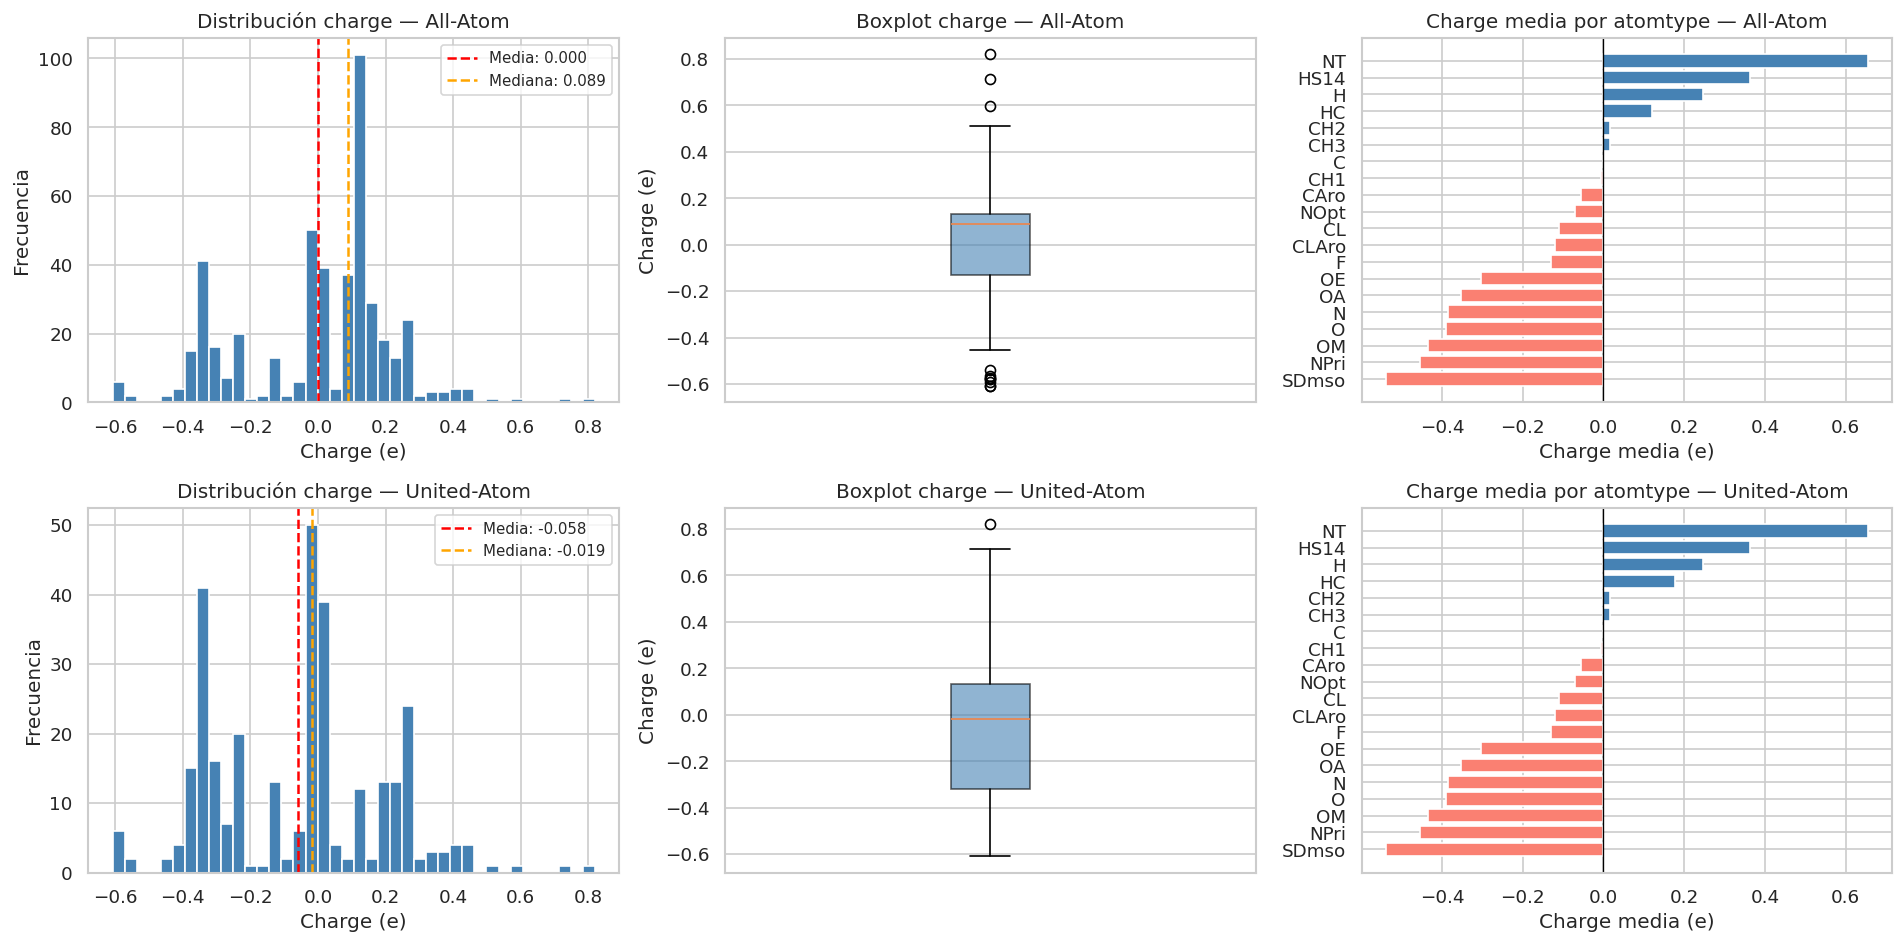


All-Atom:
  Media:    0.0003 e
  Std:      0.2251 e
  Min:      -0.6080 e
  Max:      0.8200 e
  Skewness: -0.3795
  ✓ Distribución aproximadamente simétrica.

United-Atom:
  Media:    -0.0581 e
  Std:      0.2552 e
  Min:      -0.6080 e
  Max:      0.8200 e
  Skewness: 0.2540
  ✓ Distribución aproximadamente simétrica.


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for row, (label, df) in enumerate([("All-Atom", df_AA), ("United-Atom", df_UA)]):
    charge = df["charge"]

    # Histograma
    ax = axes[row][0]
    ax.hist(charge, bins=40, color="steelblue", edgecolor="white")
    ax.axvline(charge.mean(),   color="red",    linestyle="--", label=f"Media: {charge.mean():.3f}")
    ax.axvline(charge.median(), color="orange", linestyle="--", label=f"Mediana: {charge.median():.3f}")
    ax.set_title(f"Distribución charge — {label}")
    ax.set_xlabel("Charge (e)")
    ax.set_ylabel("Frecuencia")
    ax.legend(fontsize=9)

    # Boxplot
    ax = axes[row][1]
    ax.boxplot(charge, patch_artist=True,
               boxprops=dict(facecolor="steelblue", alpha=0.6))
    ax.set_title(f"Boxplot charge — {label}")
    ax.set_ylabel("Charge (e)")
    ax.set_xticks([])

    # Charge media por atomtype
    ax = axes[row][2]
    charge_by_type = df.groupby("atomtype")["charge"].mean().sort_values()
    colors_bar = ["salmon" if v < 0 else "steelblue" for v in charge_by_type.values]
    ax.barh(charge_by_type.index, charge_by_type.values, color=colors_bar)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"Charge media por atomtype — {label}")
    ax.set_xlabel("Charge media (e)")

plt.tight_layout()
plt.show()

for label, df in [("All-Atom", df_AA), ("United-Atom", df_UA)]:
    c = df["charge"]
    print(f"\n{label}:")
    print(f"  Media:    {c.mean():.4f} e")
    print(f"  Std:      {c.std():.4f} e")
    print(f"  Min:      {c.min():.4f} e")
    print(f"  Max:      {c.max():.4f} e")
    print(f"  Skewness: {c.skew():.4f}")
    if abs(c.skew()) > 1:
        print("  ⚠ Distribución sesgada — considerar normalización del target.")
    else:
        print("  ✓ Distribución aproximadamente simétrica.")

## 6. Charge por elemento
Distribución de cargas parciales agrupada por elemento químico.
Útil para ver si el modelo de regresión tiene comportamientos distintos por elemento.


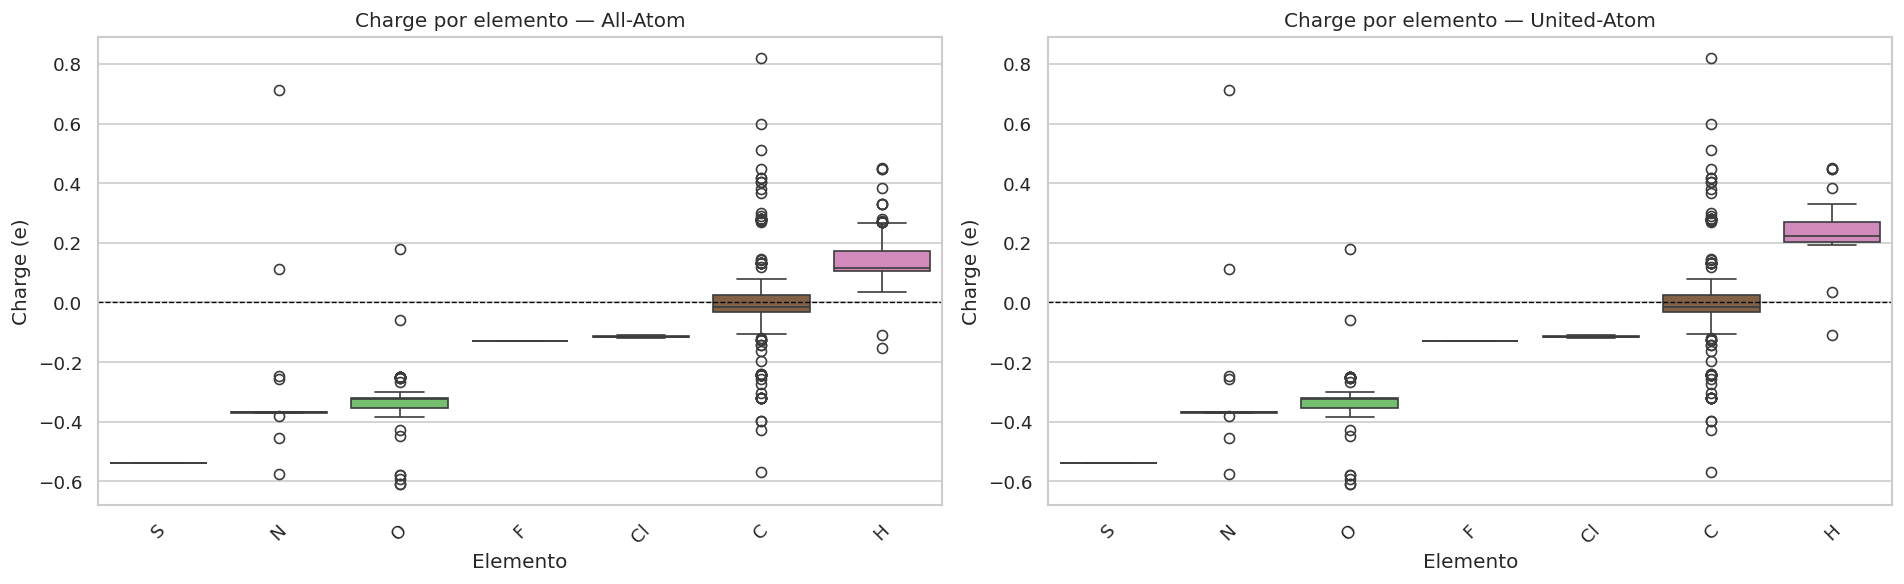

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (label, df) in zip(axes, [("All-Atom", df_AA), ("United-Atom", df_UA)]):
    sns.boxplot(data=df, x="element", y="charge", ax=ax, palette="muted",
                order=df.groupby("element")["charge"].median().sort_values().index)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"Charge por elemento — {label}")
    ax.set_xlabel("Elemento")
    ax.set_ylabel("Charge (e)")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 7. Variables booleanas

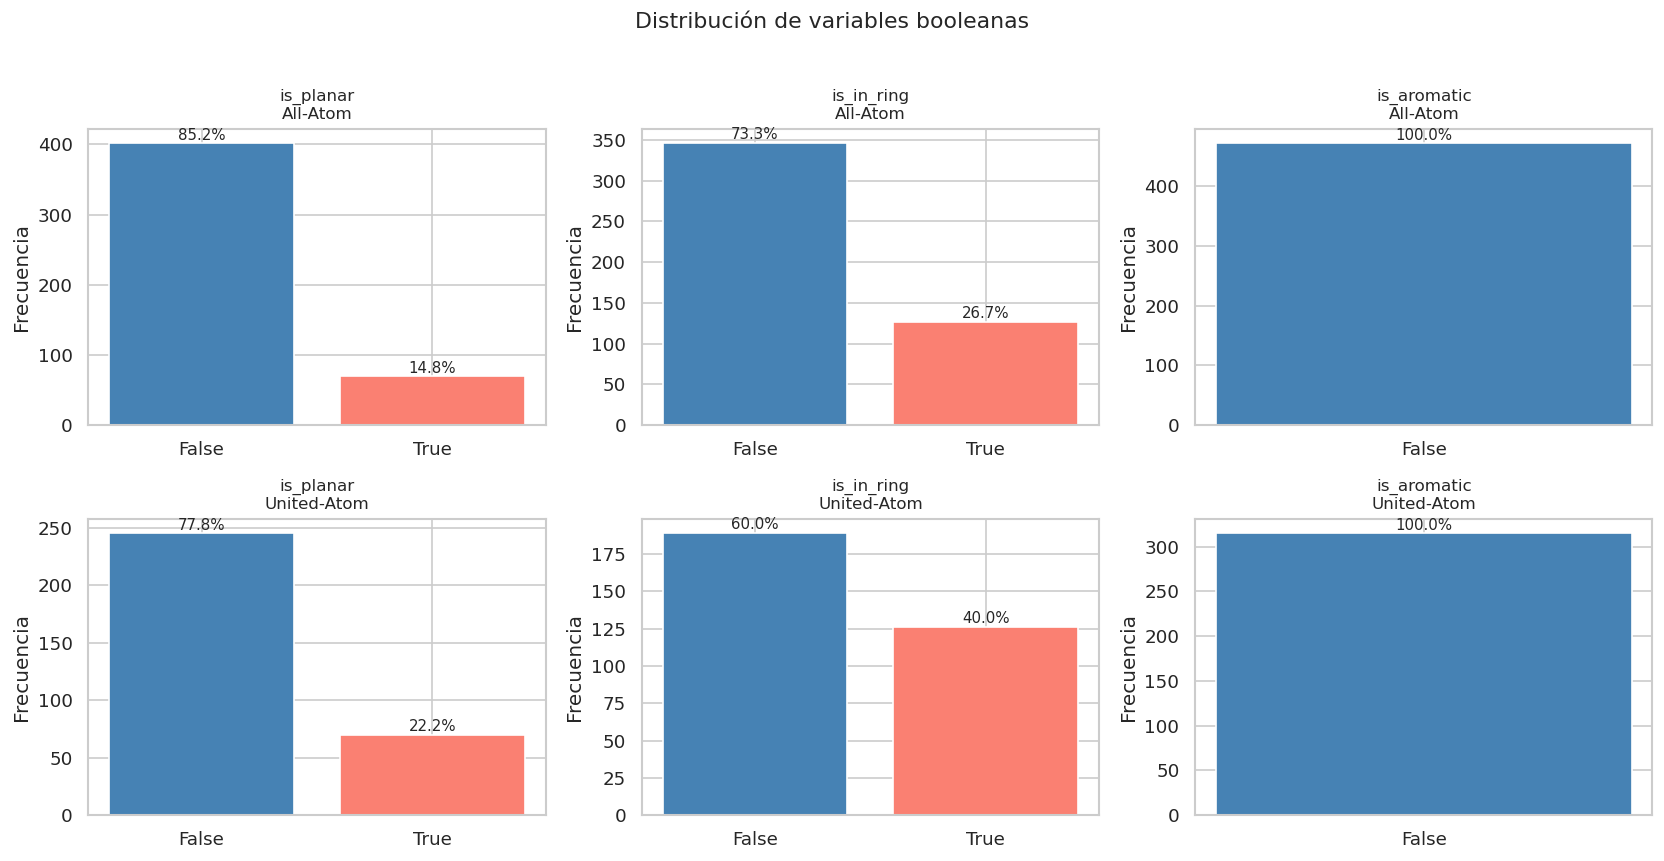

In [8]:
available_bool = [c for c in BOOL_COLS if c in df_AA.columns]

fig, axes = plt.subplots(2, len(available_bool), figsize=(14, 7))

for row, (label, df) in enumerate([("All-Atom", df_AA), ("United-Atom", df_UA)]):
    for col_i, col in enumerate(available_bool):
        ax = axes[row][col_i]
        counts = df[col].value_counts()
        ax.bar(counts.index.astype(str), counts.values,
               color=["steelblue", "salmon"][:len(counts)])
        ax.set_title(f"{col}\n{label}", fontsize=10)
        ax.set_ylabel("Frecuencia")
        for i, v in enumerate(counts.values):
            pct = v / len(df) * 100
            ax.text(i, v + len(df)*0.01, f"{pct:.1f}%", ha="center", fontsize=9)

plt.suptitle("Distribución de variables booleanas", y=1.02)
plt.tight_layout()
plt.show()

## 8. Distribución de features numéricas

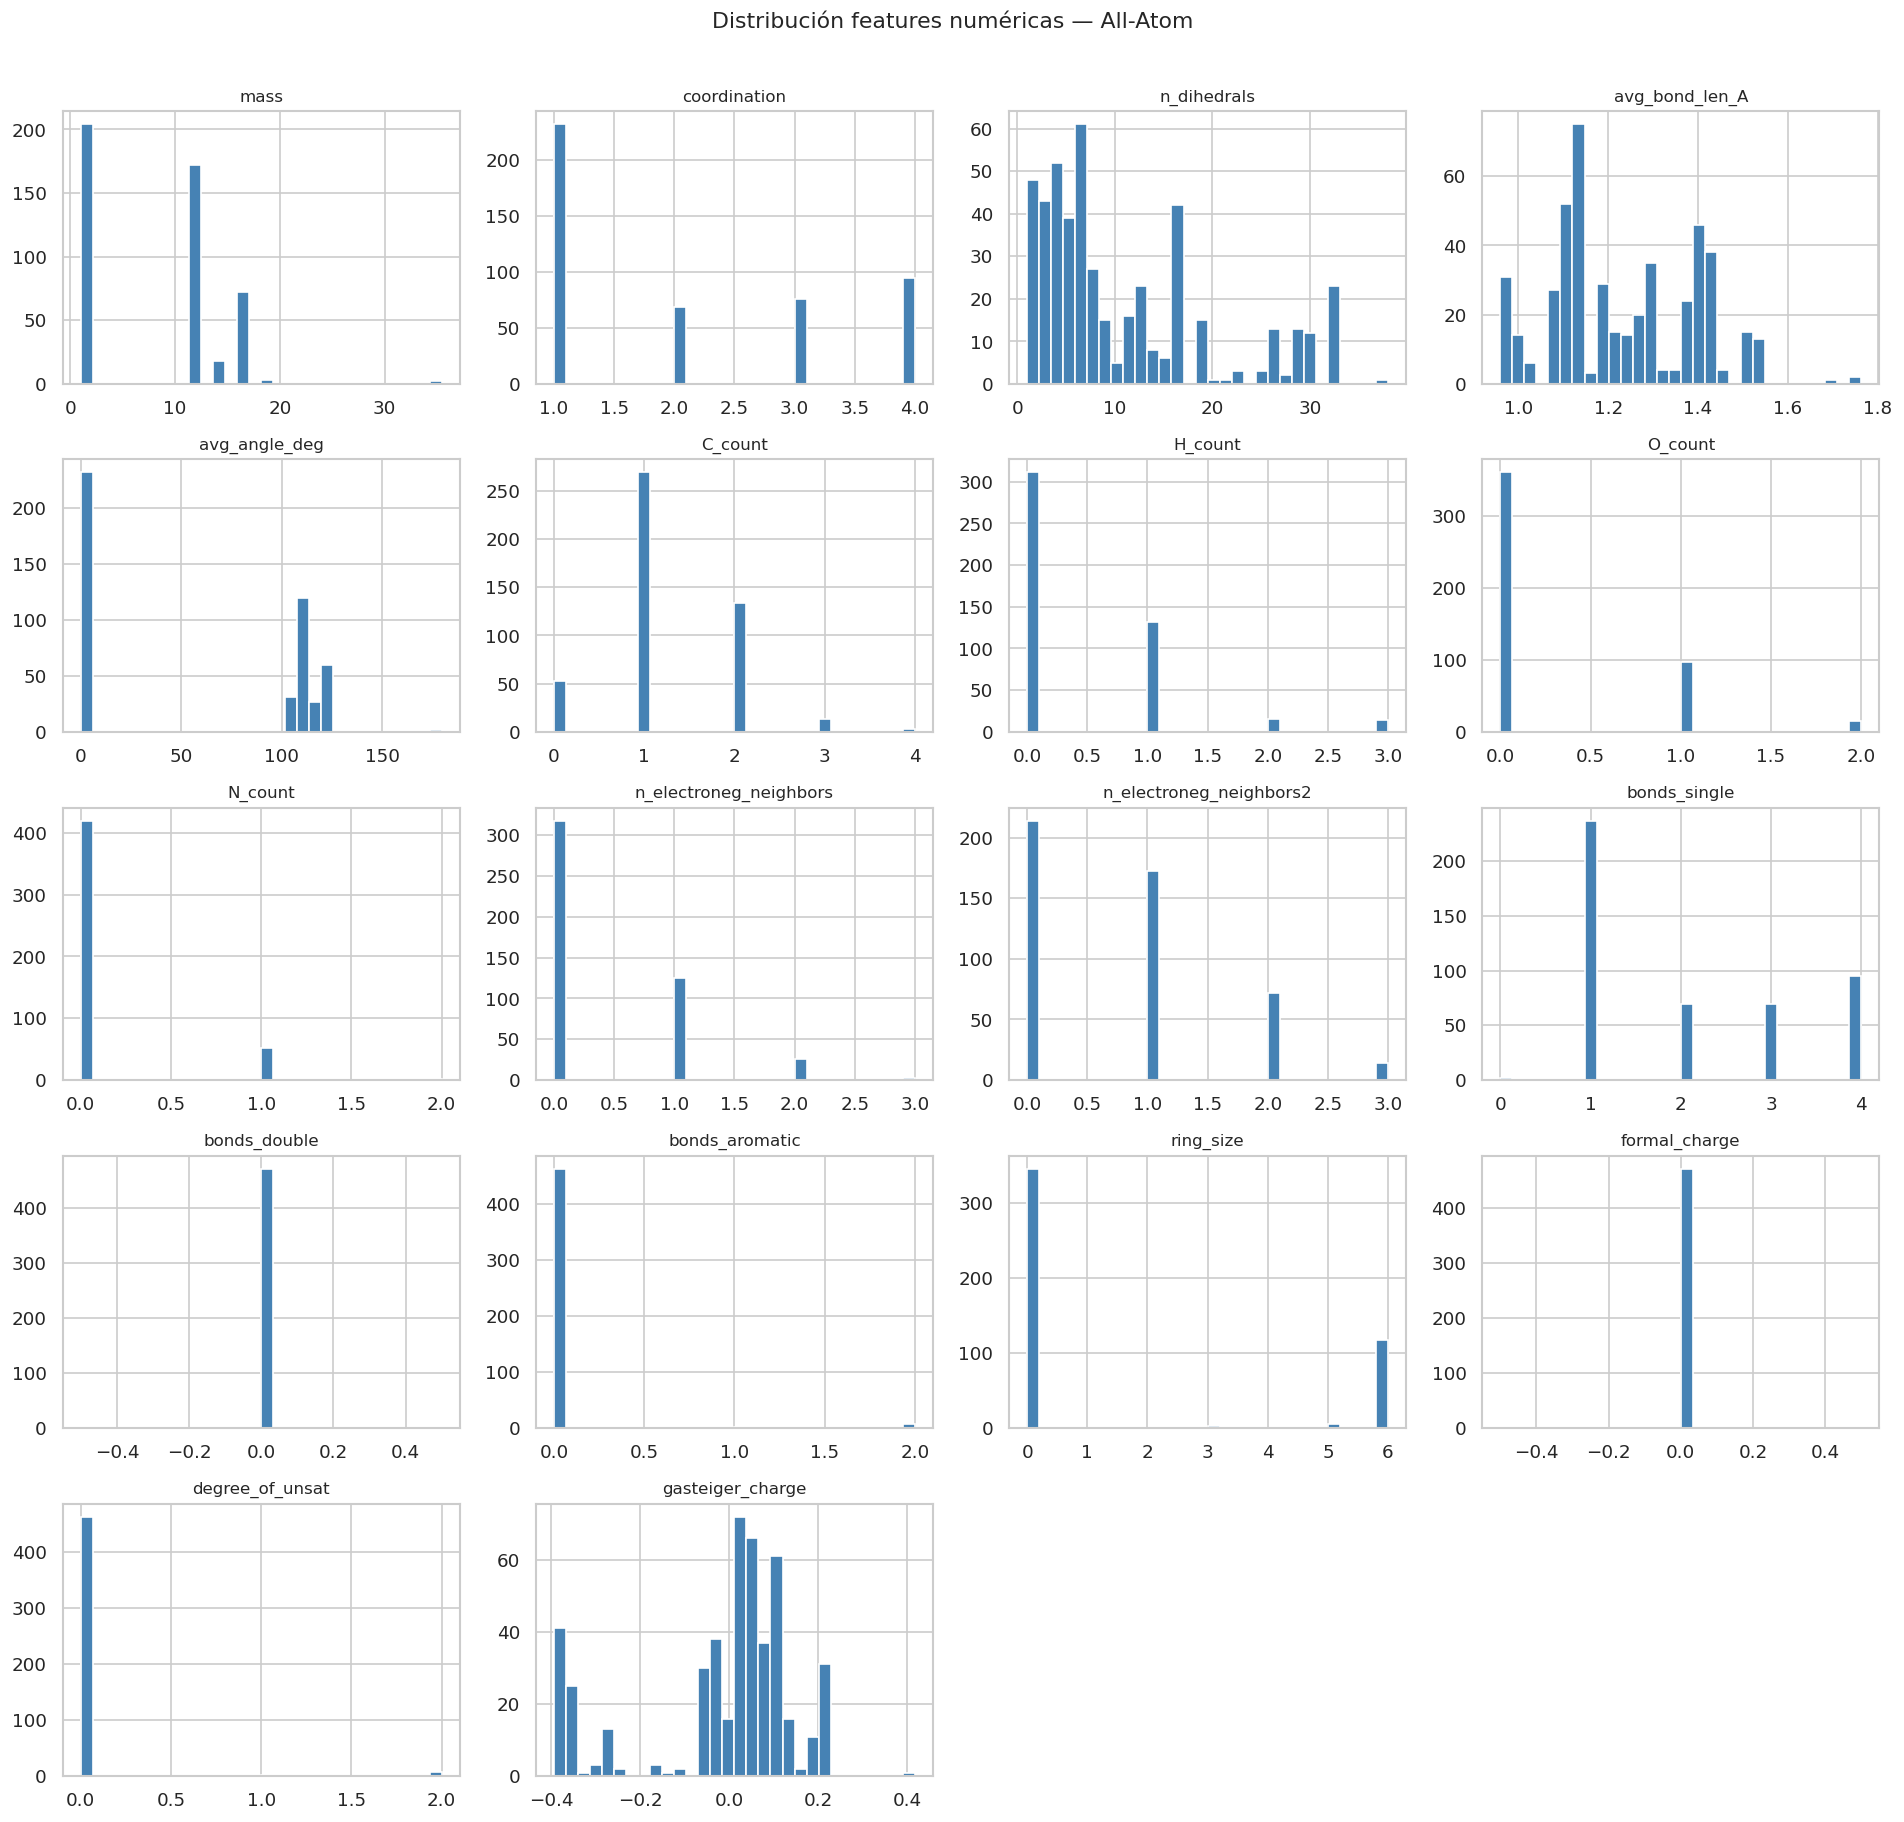

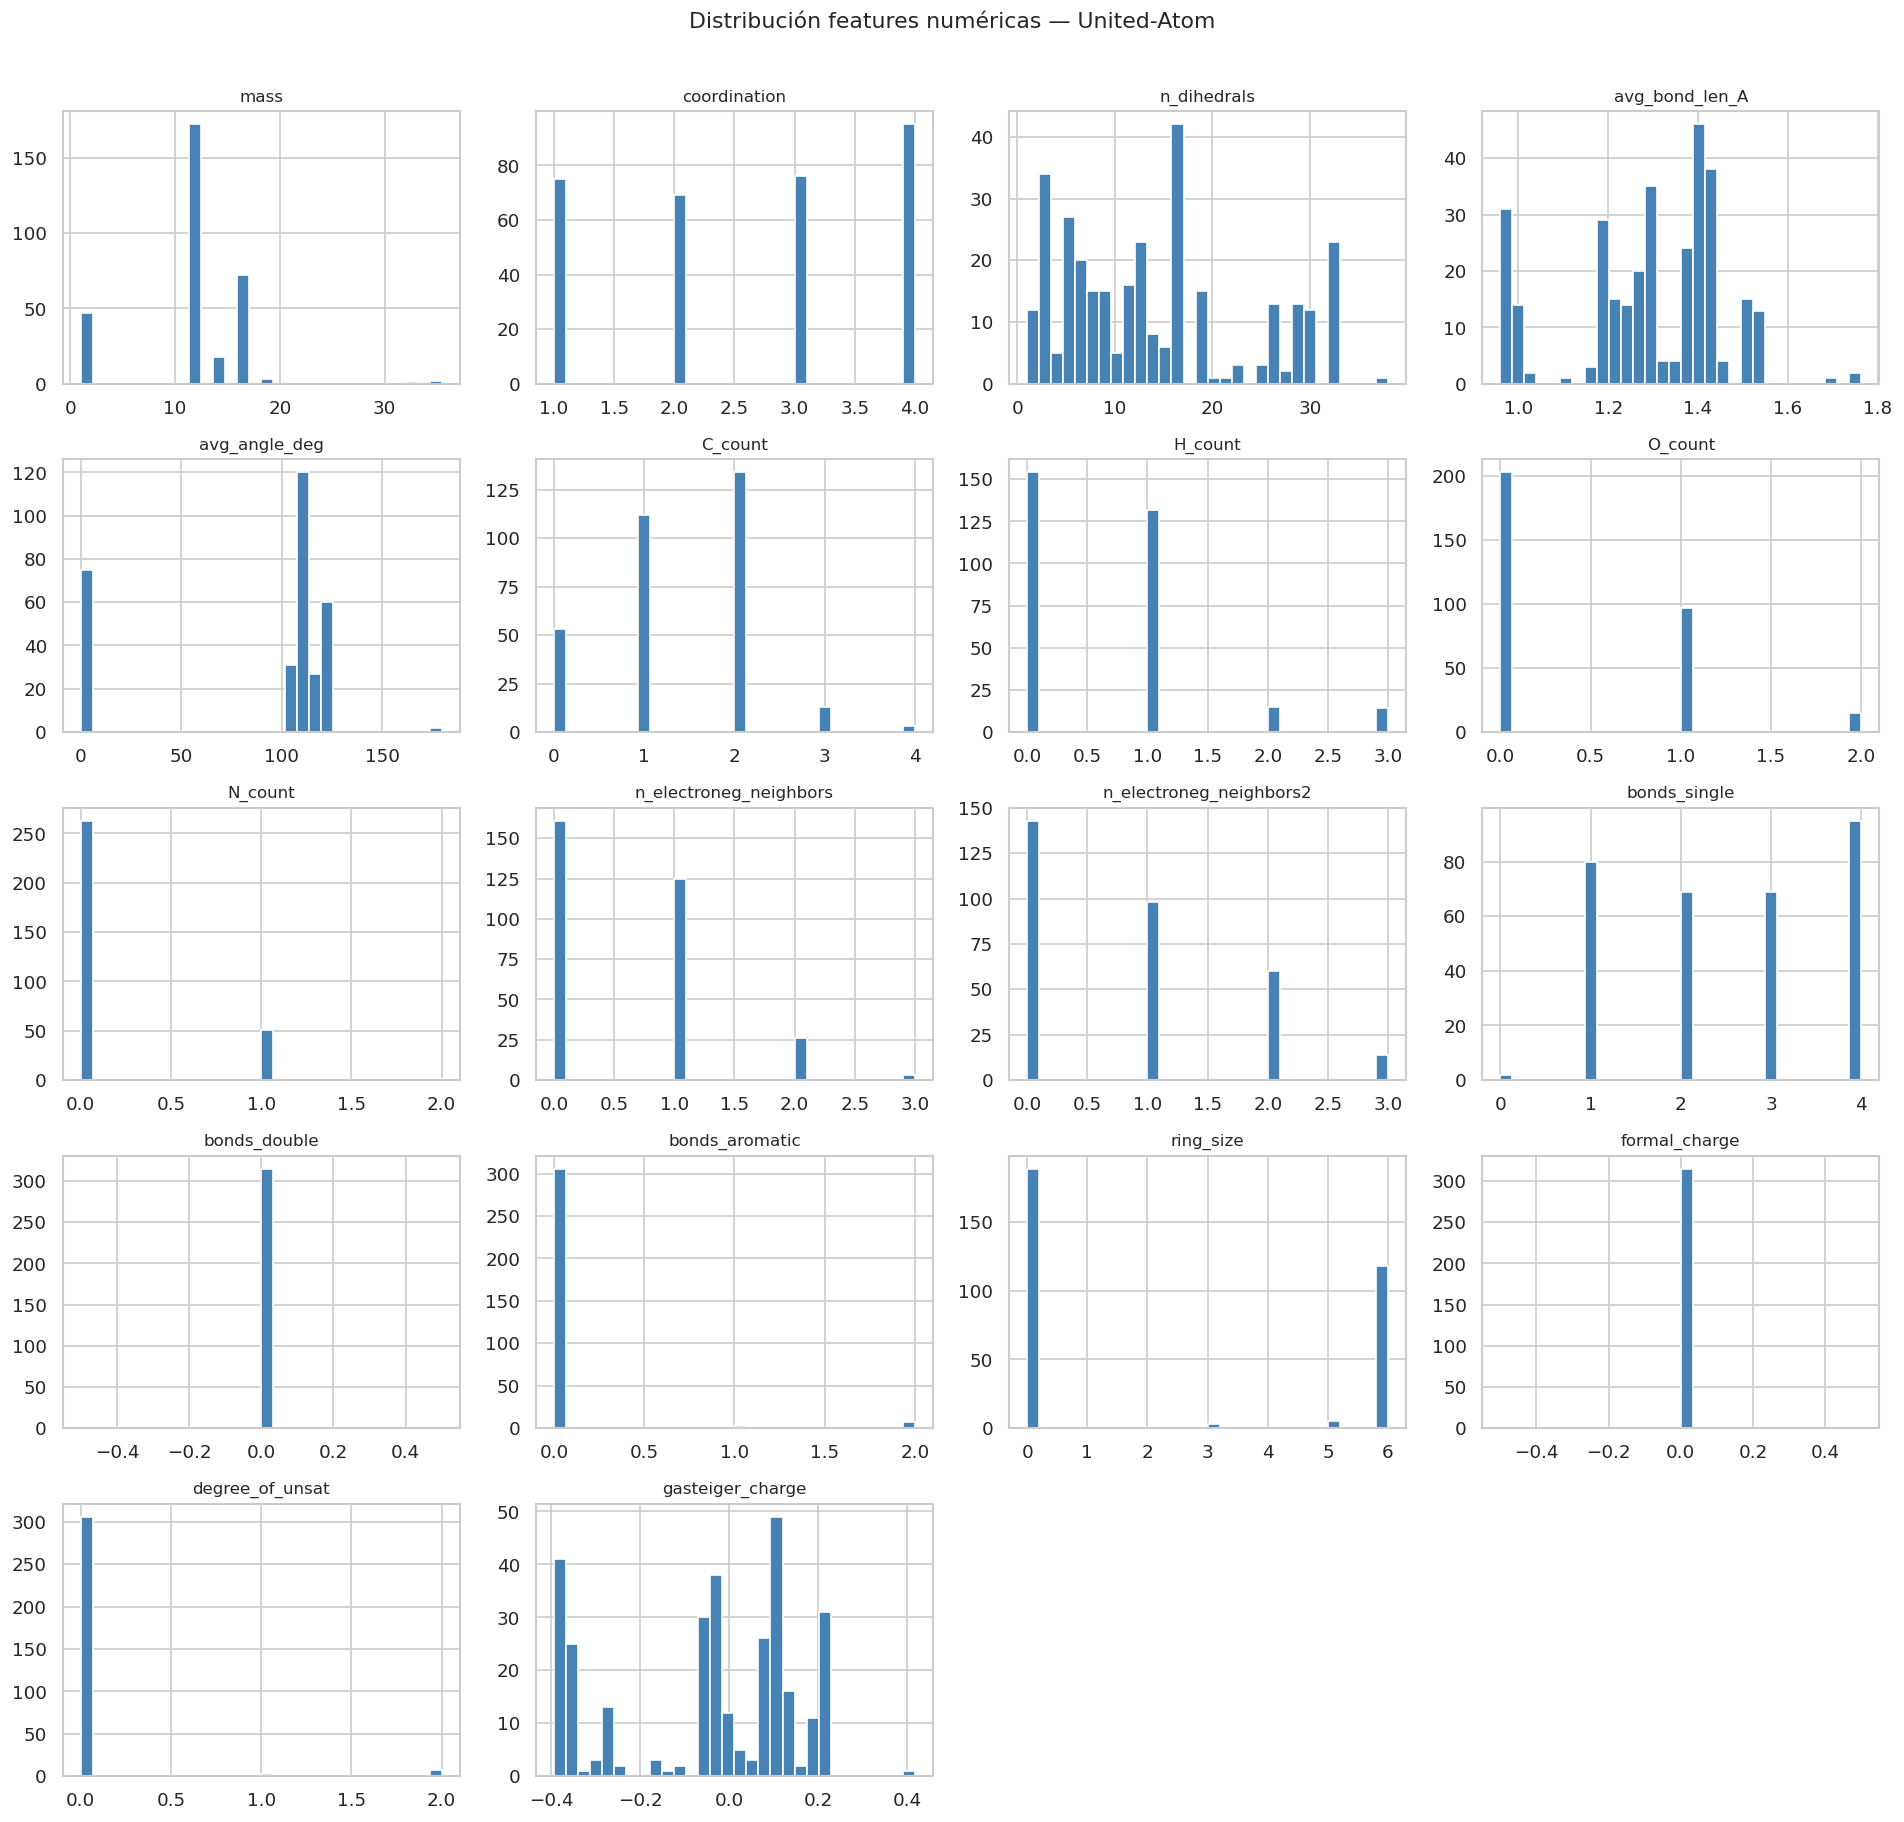

In [9]:
for label, df in [("All-Atom", df_AA), ("United-Atom", df_UA)]:
    cols  = num_cols(df)
    n_c   = 4
    n_r   = int(np.ceil(len(cols) / n_c))
    fig, axes = plt.subplots(n_r, n_c, figsize=(16, n_r * 3))
    axes  = axes.flatten()

    for i, col in enumerate(cols):
        axes[i].hist(df[col].dropna(), bins=30, color="steelblue", edgecolor="white")
        axes[i].set_title(col, fontsize=10)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f"Distribución features numéricas — {label}", y=1.01)
    plt.tight_layout()
    plt.show()

## 9. Detección de outliers (IQR)

In [10]:
for label, df in [("All-Atom", df_AA), ("United-Atom", df_UA)]:
    cols = num_cols(df)
    print(f"\n{label} — outliers por IQR:")
    found = False
    for col in cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
        if n_out > 0:
            print(f"  {col}: {n_out} outliers ({n_out/len(df)*100:.1f}%)")
            found = True
    if not found:
        print("  ✓ Sin outliers significativos.")


All-Atom — outliers por IQR:
  mass: 3 outliers (0.6%)
  n_dihedrals: 1 outliers (0.2%)
  C_count: 3 outliers (0.6%)
  H_count: 14 outliers (3.0%)
  O_count: 112 outliers (23.7%)
  N_count: 52 outliers (11.0%)
  n_electroneg_neighbors: 3 outliers (0.6%)
  n_electroneg_neighbors2: 14 outliers (3.0%)
  bonds_aromatic: 9 outliers (1.9%)
  degree_of_unsat: 9 outliers (1.9%)
  gasteiger_charge: 84 outliers (17.8%)

United-Atom — outliers por IQR:
  mass: 53 outliers (16.8%)
  avg_bond_len_A: 2 outliers (0.6%)
  avg_angle_deg: 77 outliers (24.4%)
  C_count: 3 outliers (1.0%)
  H_count: 14 outliers (4.4%)
  N_count: 52 outliers (16.5%)
  n_electroneg_neighbors: 3 outliers (1.0%)
  n_electroneg_neighbors2: 14 outliers (4.4%)
  bonds_aromatic: 9 outliers (2.9%)
  degree_of_unsat: 9 outliers (2.9%)


## 10. Correlación features numéricas vs charge
Qué features están más correlacionadas con el target de regresión.


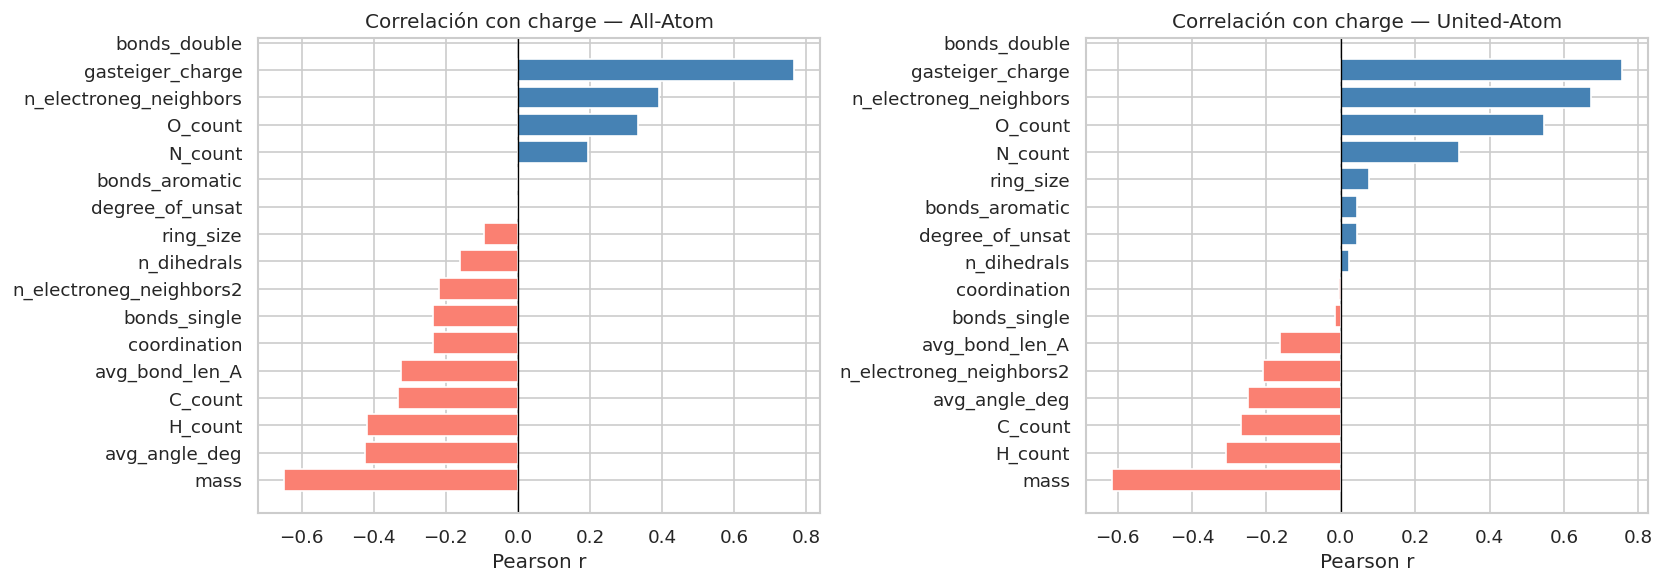


All-Atom — top 5 features más correlacionadas con charge:
gasteiger_charge          0.767576
mass                      0.649563
avg_angle_deg             0.424123
H_count                   0.418891
n_electroneg_neighbors    0.391436

United-Atom — top 5 features más correlacionadas con charge:
gasteiger_charge          0.756235
n_electroneg_neighbors    0.671759
mass                      0.616353
O_count                   0.547624
N_count                   0.318400


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, df) in zip(axes, [("All-Atom", df_AA), ("United-Atom", df_UA)]):
    cols  = num_cols(df)
    corrs = df[cols + ["charge"]].corr()["charge"].drop("charge").sort_values()
    colors = ["salmon" if v < 0 else "steelblue" for v in corrs.values]
    ax.barh(corrs.index, corrs.values, color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"Correlación con charge — {label}")
    ax.set_xlabel("Pearson r")

plt.tight_layout()
plt.show()

for label, df in [("All-Atom", df_AA), ("United-Atom", df_UA)]:
    cols  = num_cols(df)
    corrs = df[cols + ["charge"]].corr()["charge"].drop("charge").abs().sort_values(ascending=False)
    print(f"\n{label} — top 5 features más correlacionadas con charge:")
    print(corrs.head(5).to_string())

## 11. Matriz de correlación entre features numéricas

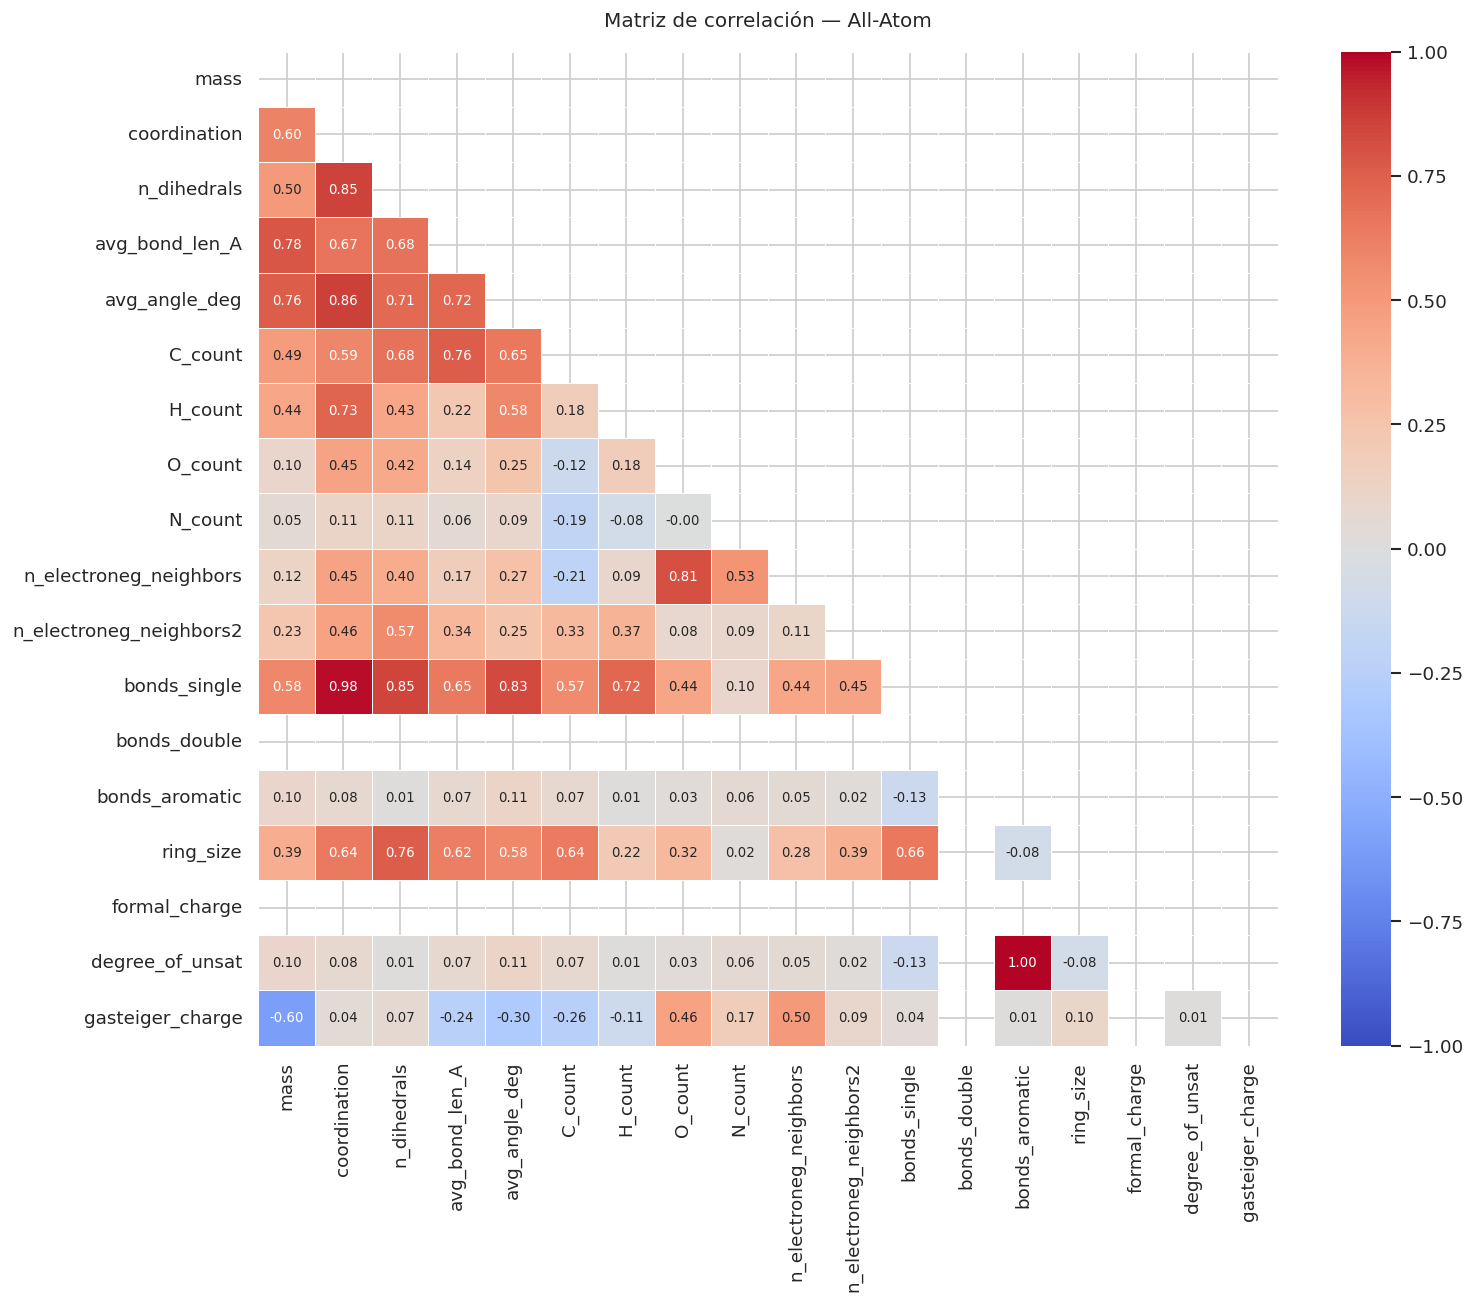


All-Atom — pares con |r| > 0.8:
  bonds_aromatic ↔ degree_of_unsat: r = 1.0
  coordination ↔ bonds_single: r = 0.979
  coordination ↔ avg_angle_deg: r = 0.861
  coordination ↔ n_dihedrals: r = 0.854
  n_dihedrals ↔ bonds_single: r = 0.846
  avg_angle_deg ↔ bonds_single: r = 0.833
  O_count ↔ n_electroneg_neighbors: r = 0.807
  ⚠ Evaluar eliminación de features redundantes.


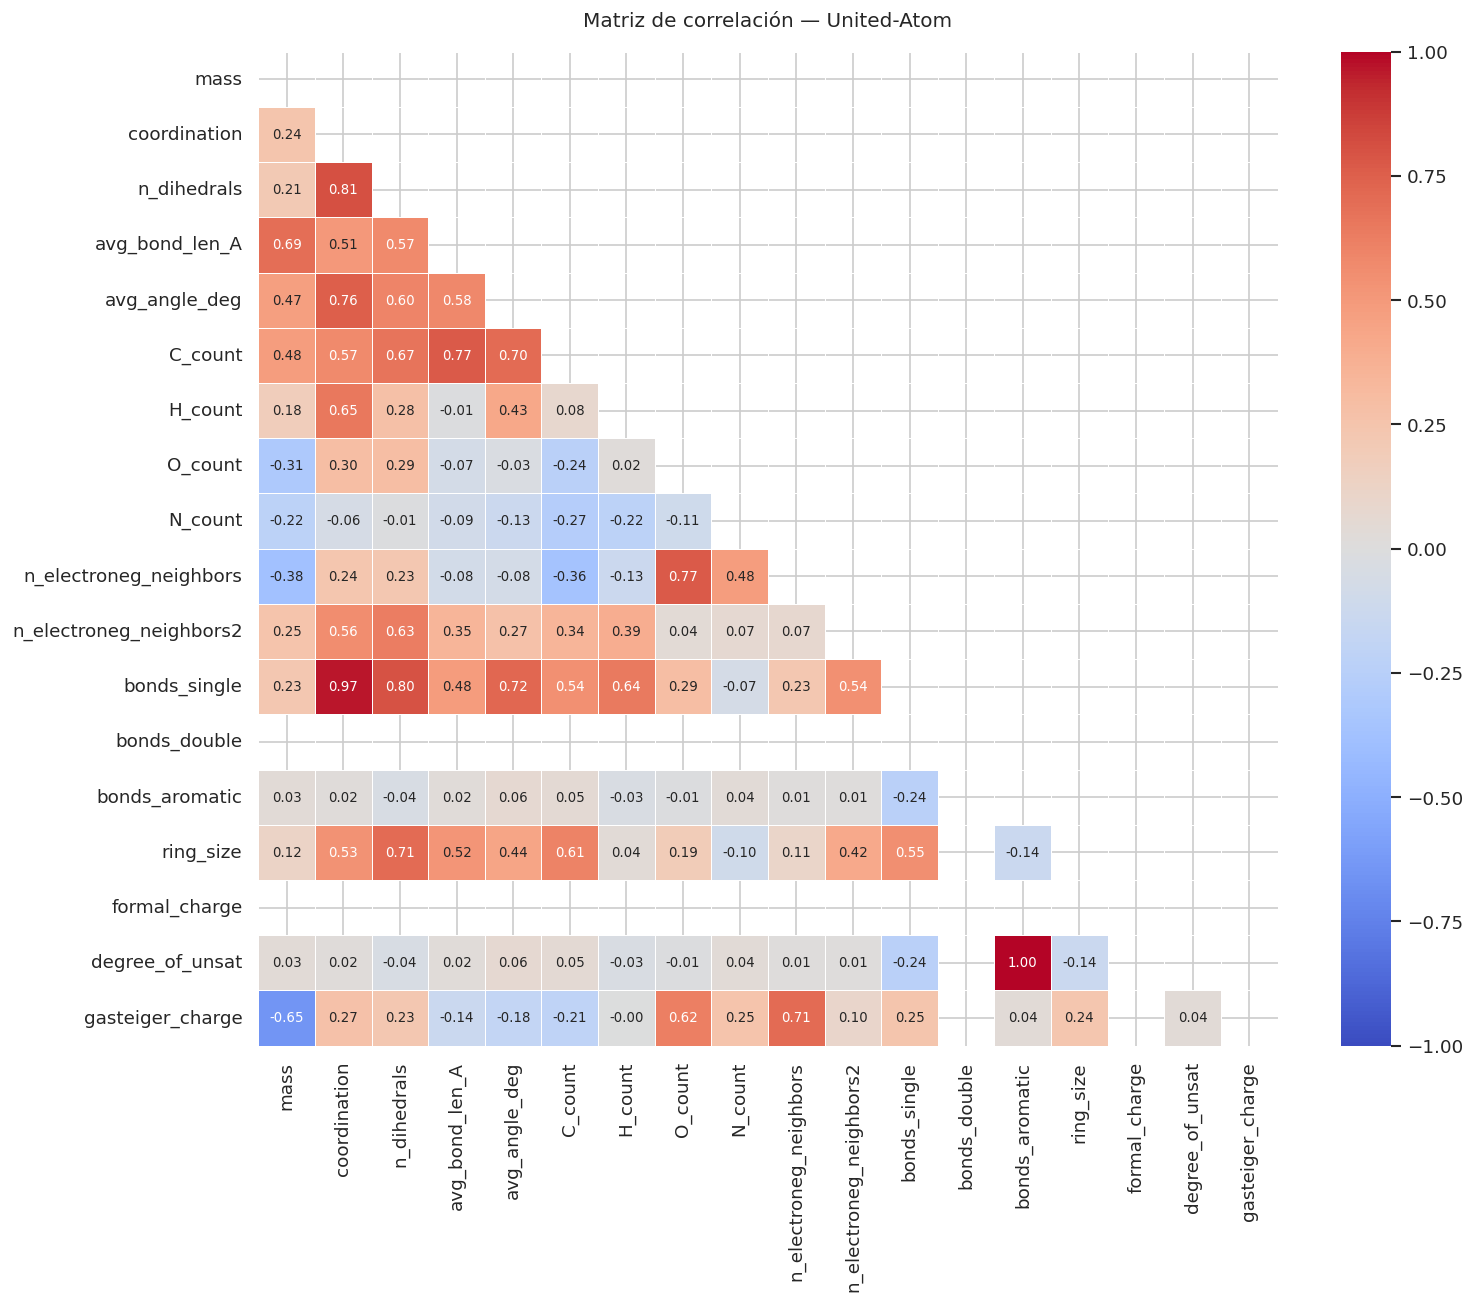


United-Atom — pares con |r| > 0.8:
  bonds_aromatic ↔ degree_of_unsat: r = 1.0
  coordination ↔ bonds_single: r = 0.966
  coordination ↔ n_dihedrals: r = 0.812
  ⚠ Evaluar eliminación de features redundantes.


In [12]:
for label, df in [("All-Atom", df_AA), ("United-Atom", df_UA)]:
    cols = num_cols(df)
    corr = df[cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, ax = plt.subplots(figsize=(13, 11))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
                center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
                annot_kws={"size": 8})
    ax.set_title(f"Matriz de correlación — {label}", pad=15)
    plt.tight_layout()
    plt.show()

    high_corr = [
        (corr.columns[i], corr.columns[j], round(corr.iloc[i, j], 3))
        for i in range(len(corr.columns))
        for j in range(i + 1, len(corr.columns))
        if abs(corr.iloc[i, j]) > 0.8
    ]
    print(f"\n{label} — pares con |r| > 0.8:")
    if high_corr:
        for a, b, r in sorted(high_corr, key=lambda x: -abs(x[2])):
            print(f"  {a} ↔ {b}: r = {r}")
        print("  ⚠ Evaluar eliminación de features redundantes.")
    else:
        print("  ✓ Sin multicolinealidad problemática.")

## 12. Análisis de neighbor_config y neighbor2_config
Configuraciones de vecinos más frecuentes y detección de configuraciones raras
que pueden ser problemáticas para el modelo.


In [13]:
for label, df in [("All-Atom", df_AA), ("United-Atom", df_UA)]:
    print(f"\n{label}:")
    for col in ["neighbor_config", "neighbor2_config"]:
        if col not in df.columns:
            continue
        n_unique = df[col].nunique()
        counts   = df[col].value_counts()
        rare     = counts[counts < RARE_THRESHOLD]
        print(f"  {col}: {n_unique} configuraciones únicas")
        print(f"  Top 10:")
        print(counts.head(10).to_string())
        if not rare.empty:
            print(f"  ⚠ {len(rare)} configuraciones con menos de {RARE_THRESHOLD} instancias")
            print("    → Considerar hashing o agrupamiento en preprocesamiento.")
        print()


All-Atom:
  neighbor_config: 32 configuraciones únicas
  Top 10:
neighbor_config
C1             181
C1-C1-H1-O1     37
C1-C1           37
C1-C1-H1        33
O1              31
C1-H1           31
N1              18
C1-H1-H1-H1     14
C1-H1-O1-O1     12
C1-C1-H1-N1     12
  ⚠ 19 configuraciones con menos de 5 instancias
    → Considerar hashing o agrupamiento en preprocesamiento.

  neighbor2_config: 53 configuraciones únicas
  Top 10:
neighbor2_config
C-H-H            54
C-C              49
C-C-O            38
C                32
C-H-O            25
C-C-C-H-H-O      23
C-C-H            20
C-N              14
C-C-H-H-H-O-O    13
N-O              13
  ⚠ 30 configuraciones con menos de 5 instancias
    → Considerar hashing o agrupamiento en preprocesamiento.


United-Atom:
  neighbor_config: 32 configuraciones únicas
  Top 10:
neighbor_config
C1-C1          37
C1-C1-H1-O1    37
C1-C1-H1       33
C1-H1          31
O1             31
C1             24
N1             18
C1-H1-H1-H1    14
C1-H

## 13. Features clave por atomtype

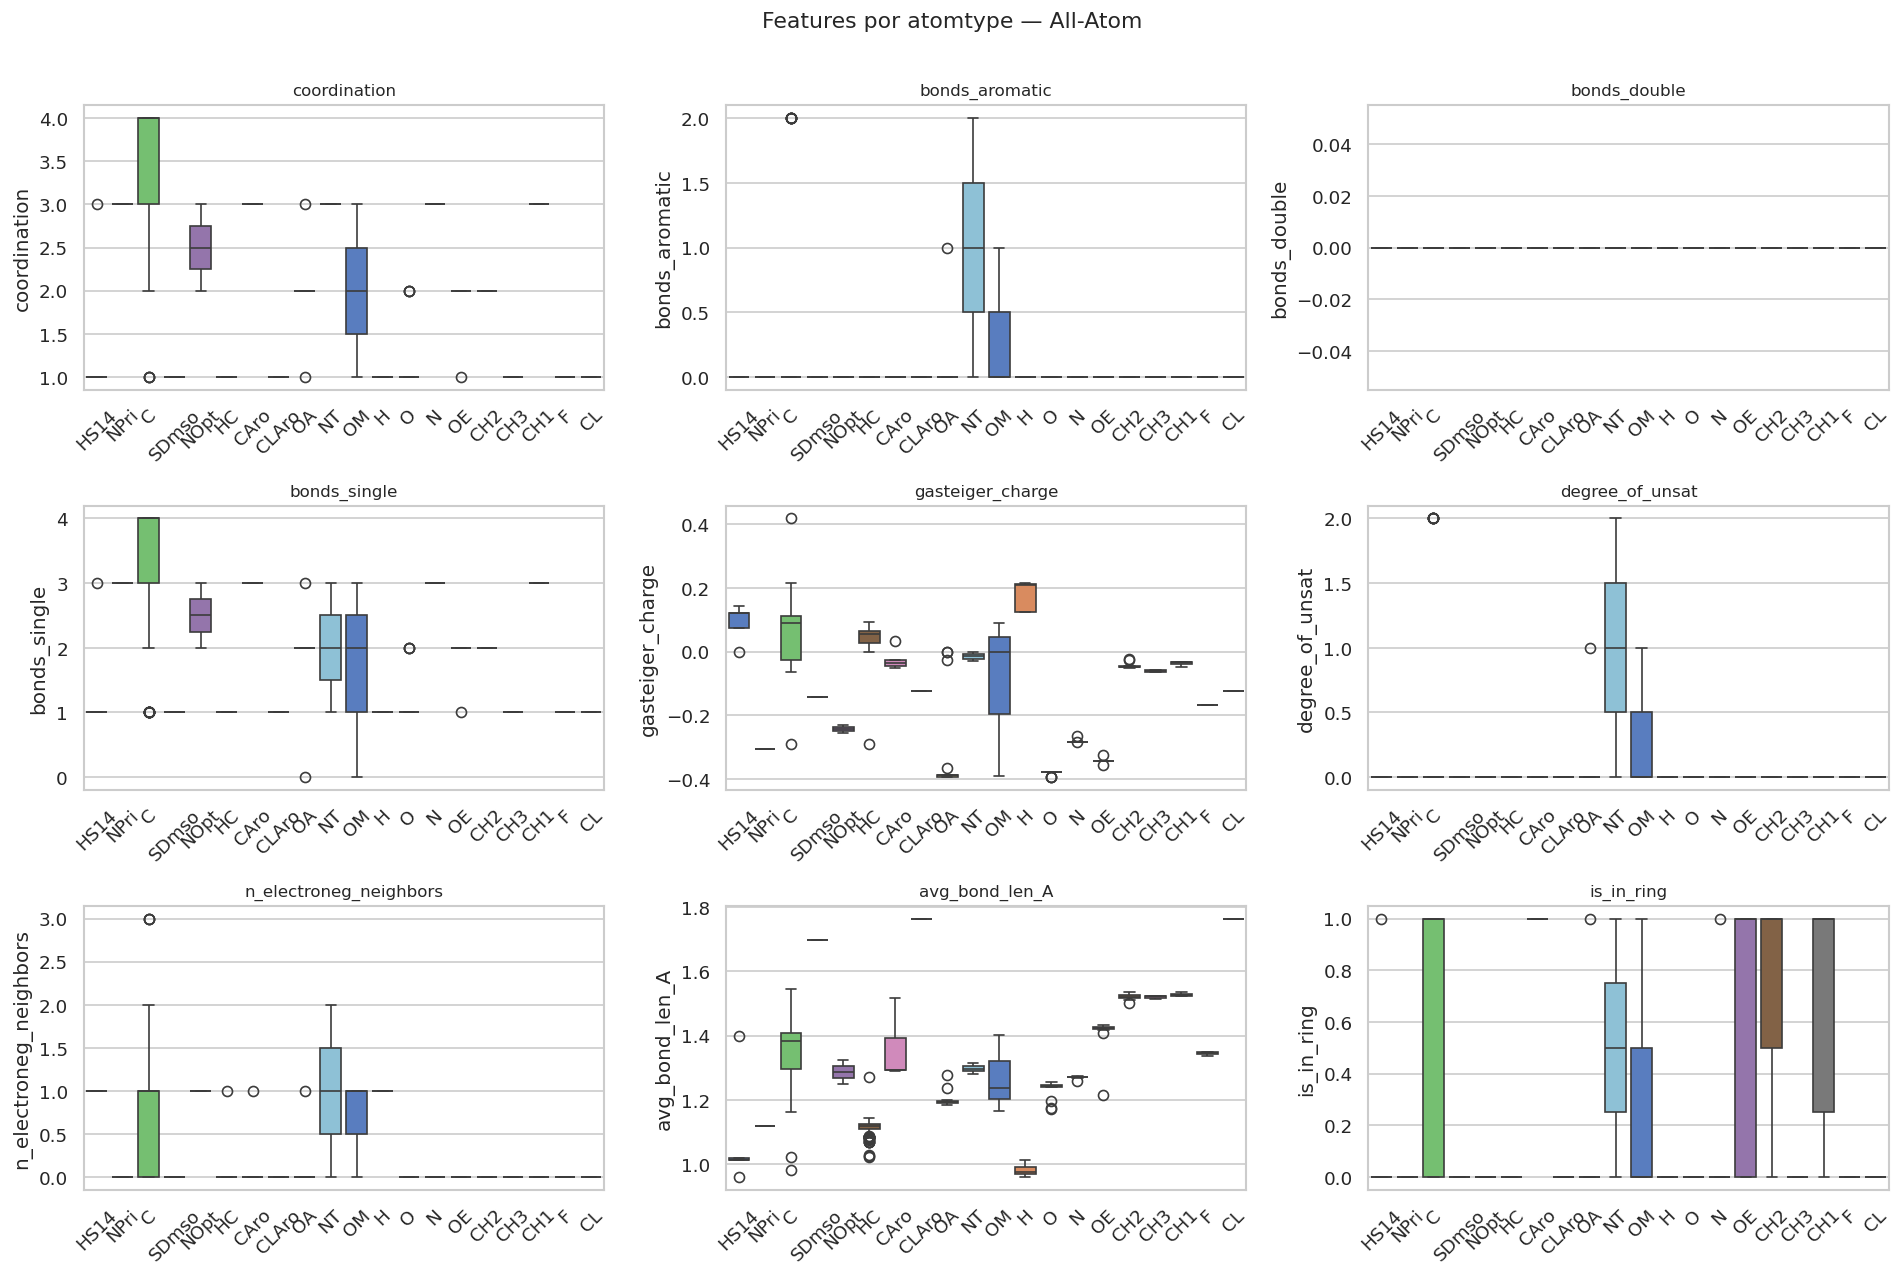

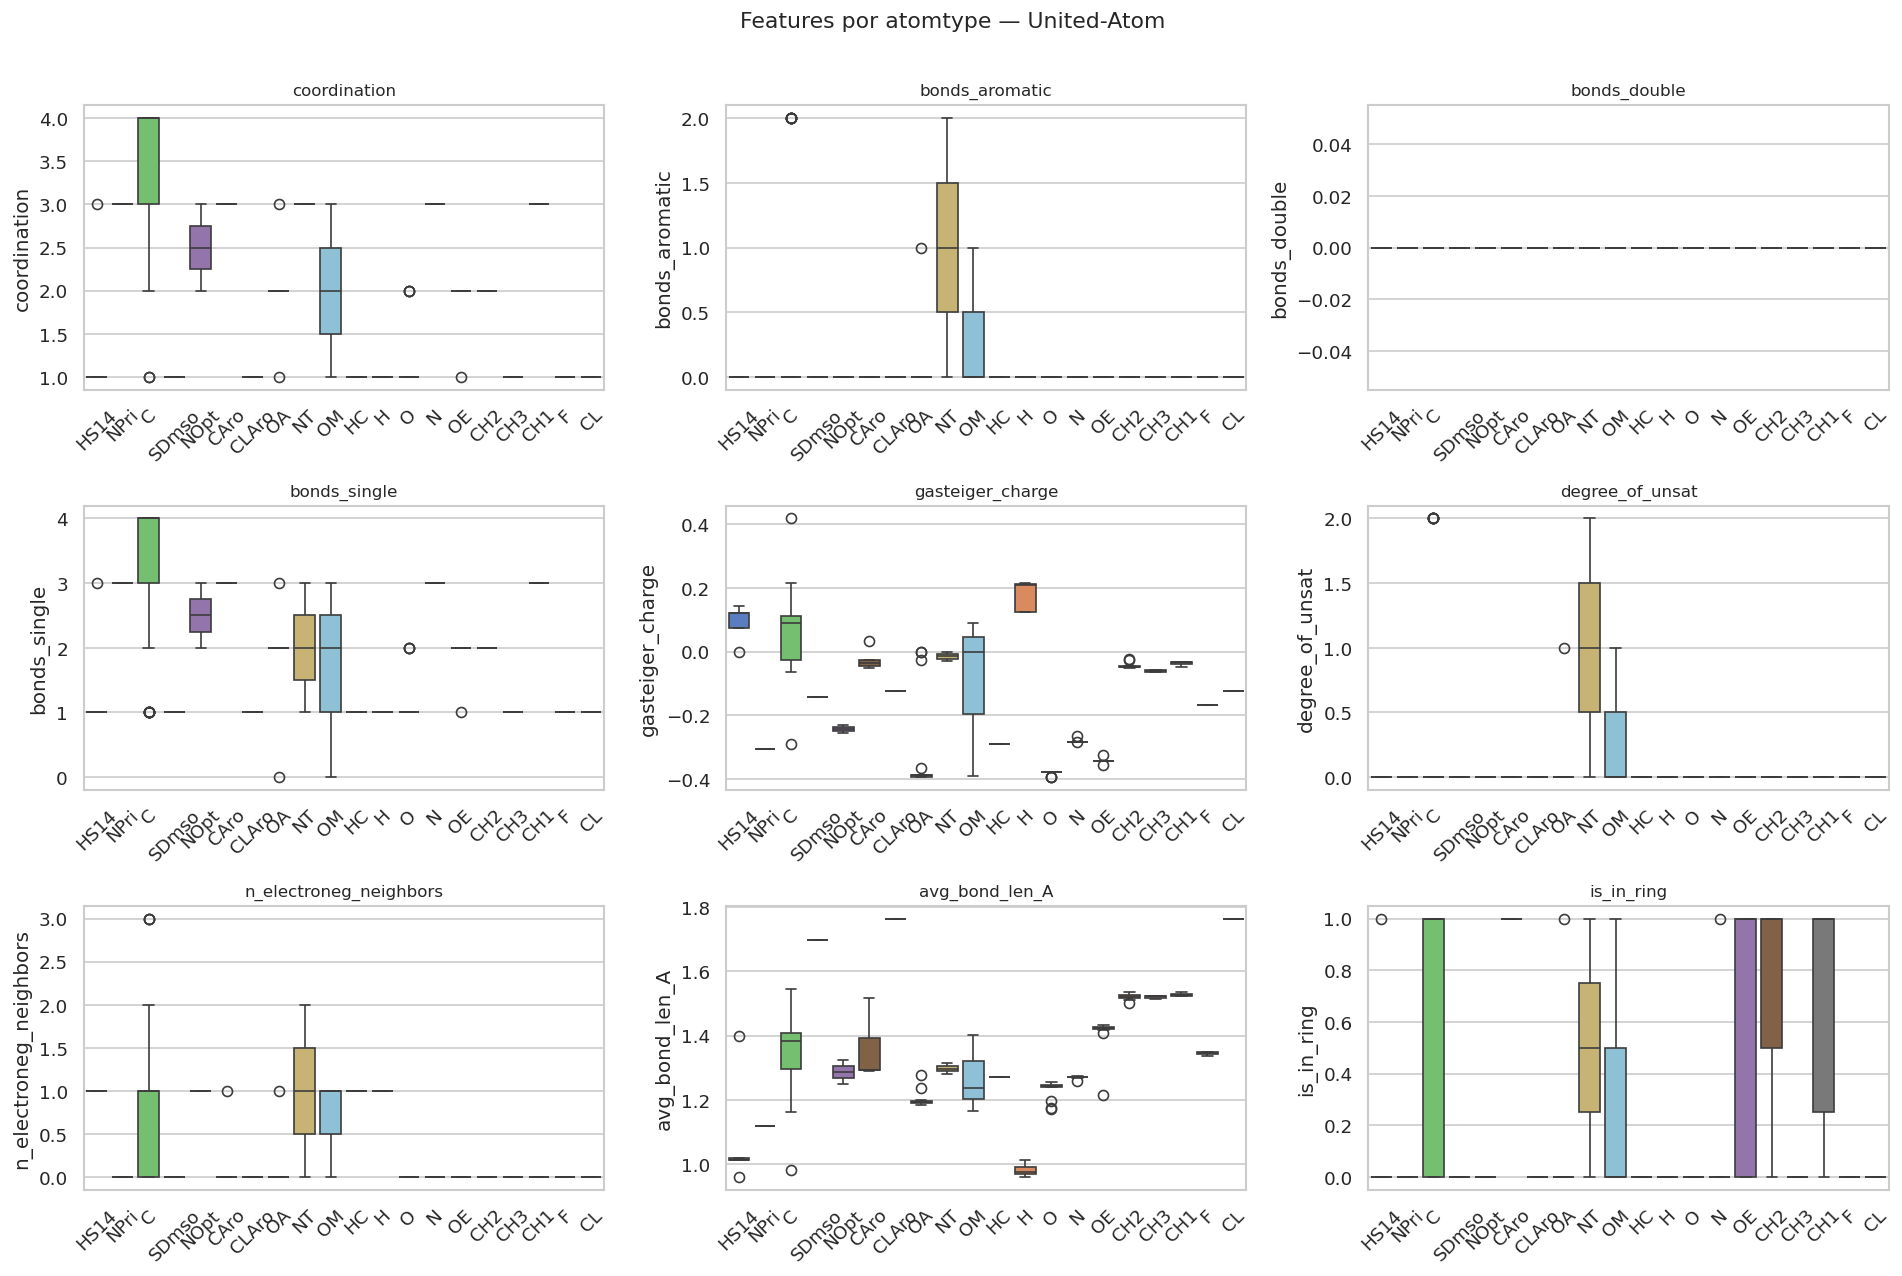

In [14]:
key_features = [
    "coordination", "bonds_aromatic", "bonds_double", "bonds_single",
    "gasteiger_charge", "degree_of_unsat", "n_electroneg_neighbors",
    "avg_bond_len_A", "is_in_ring",
]

for label, df in [("All-Atom", df_AA), ("United-Atom", df_UA)]:
    feats = [f for f in key_features if f in df.columns]
    n_c   = 3
    n_r   = int(np.ceil(len(feats) / n_c))
    fig, axes = plt.subplots(n_r, n_c, figsize=(16, n_r * 3.5))
    axes = axes.flatten()

    for i, feat in enumerate(feats):
        sns.boxplot(data=df, x="atomtype", y=feat, ax=axes[i], palette="muted")
        axes[i].set_title(feat, fontsize=10)
        axes[i].set_xlabel("")
        axes[i].tick_params(axis="x", rotation=45)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f"Features por atomtype — {label}", y=1.01)
    plt.tight_layout()
    plt.show()

## 14. Resumen y decisiones para el preprocesamiento

In [15]:
for label, df in [("All-Atom", df_AA), ("United-Atom", df_UA)]:
    counts = df["atomtype"].value_counts()
    ratio  = counts.max() / counts.min()
    rare   = counts[counts < RARE_THRESHOLD]
    cols   = num_cols(df)
    corr   = df[cols].corr()
    high_corr = [
        (corr.columns[i], corr.columns[j])
        for i in range(len(corr.columns))
        for j in range(i + 1, len(corr.columns))
        if abs(corr.iloc[i, j]) > 0.8
    ]

    print(f"\n{'='*55}")
    print(f"  RESUMEN — {label}")
    print(f"{'='*55}")
    print(f"  Átomos:               {len(df)}")
    print(f"  Clases de atomtype:   {df['atomtype'].nunique()}")
    print(f"  Rango de charge:      [{df['charge'].min():.3f}, {df['charge'].max():.3f}]")
    print()
    print("  DECISIONES SUGERIDAS:")

    if ratio > 5:
        print(f"  ⚠ Desbalance ({ratio:.1f}x) → class_weight='balanced' al entrenar.")
    else:
        print(f"  ✓ Clases balanceadas (ratio {ratio:.1f}x).")

    if not rare.empty:
        print(f"  ⚠ {len(rare)} clase(s) rara(s) → evaluar agrupamiento o eliminación.")
    else:
        print("  ✓ Sin clases raras.")

    if abs(df["charge"].skew()) > 1:
        print(f"  ⚠ Charge sesgada (skew={df['charge'].skew():.2f}) → evaluar normalización.")
    else:
        print(f"  ✓ Charge simétrica (skew={df['charge'].skew():.2f}).")

    if high_corr:
        print(f"  ⚠ {len(high_corr)} par(es) con alta correlación → evaluar eliminación.")
    else:
        print("  ✓ Sin multicolinealidad problemática.")

    for col in ["neighbor_config", "neighbor2_config"]:
        if col in df.columns:
            n_u = df[col].nunique()
            print(f"  → {col}: {n_u} valores únicos → aplicar hashing en preprocesamiento.")


  RESUMEN — All-Atom
  Átomos:               472
  Clases de atomtype:   20
  Rango de charge:      [-0.608, 0.820]

  DECISIONES SUGERIDAS:
  ⚠ Desbalance (157.0x) → class_weight='balanced' al entrenar.
  ⚠ 8 clase(s) rara(s) → evaluar agrupamiento o eliminación.
  ✓ Charge simétrica (skew=-0.38).
  ⚠ 7 par(es) con alta correlación → evaluar eliminación.
  → neighbor_config: 32 valores únicos → aplicar hashing en preprocesamiento.
  → neighbor2_config: 53 valores únicos → aplicar hashing en preprocesamiento.

  RESUMEN — United-Atom
  Átomos:               315
  Clases de atomtype:   20
  Rango de charge:      [-0.608, 0.820]

  DECISIONES SUGERIDAS:
  ⚠ Desbalance (143.0x) → class_weight='balanced' al entrenar.
  ⚠ 9 clase(s) rara(s) → evaluar agrupamiento o eliminación.
  ✓ Charge simétrica (skew=0.25).
  ⚠ 3 par(es) con alta correlación → evaluar eliminación.
  → neighbor_config: 32 valores únicos → aplicar hashing en preprocesamiento.
  → neighbor2_config: 52 valores únicos → apl

In [16]:
# Clases raras
print(df_AA["atomtype"].value_counts().tail(10))

# Pares correlacionados
cols = num_cols(df_AA)
corr = df_AA[cols].corr()
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i,j]) > 0.8:
            print(f"{corr.columns[i]} ↔ {corr.columns[j]}: {corr.iloc[i,j]:.3f}")

atomtype
HS14     5
CH3      5
F        3
OM       3
NOpt     2
NT       2
SDmso    1
NPri     1
CLAro    1
CL       1
Name: count, dtype: int64
coordination ↔ n_dihedrals: 0.854
coordination ↔ avg_angle_deg: 0.861
coordination ↔ bonds_single: 0.979
n_dihedrals ↔ bonds_single: 0.846
avg_angle_deg ↔ bonds_single: 0.833
O_count ↔ n_electroneg_neighbors: 0.807
bonds_aromatic ↔ degree_of_unsat: 1.000


In [17]:
# Clases raras
print(df_UA["atomtype"].value_counts().tail(10))

# Pares correlacionados
cols = num_cols(df_AA)
corr = df_AA[cols].corr()
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i,j]) > 0.8:
            print(f"{corr.columns[i]} ↔ {corr.columns[j]}: {corr.iloc[i,j]:.3f}")

atomtype
HS14     5
OM       3
F        3
NT       2
NOpt     2
NPri     1
SDmso    1
CLAro    1
HC       1
CL       1
Name: count, dtype: int64
coordination ↔ n_dihedrals: 0.854
coordination ↔ avg_angle_deg: 0.861
coordination ↔ bonds_single: 0.979
n_dihedrals ↔ bonds_single: 0.846
avg_angle_deg ↔ bonds_single: 0.833
O_count ↔ n_electroneg_neighbors: 0.807
bonds_aromatic ↔ degree_of_unsat: 1.000


A raiz de los resultados, corro lo siguiente

In [18]:
print(df_UA[df_UA["atomtype"] == "HC"][["molecule", "atom_name", "element", "bonded_to_element", "atomtype"]])

   molecule atom_name element bonded_to_element atomtype
24      2NP         O       O                 N       HC


In [19]:
for at in ["HS14", "OM", "F", "NT", "NOpt", "NPri", "SDmso", "CLAro", "CL"]:
    n_aa = (df_AA["atomtype"] == at).sum()
    n_ua = (df_UA["atomtype"] == at).sum()
    print(f"{at:10s}  AA: {n_aa}  UA: {n_ua}")

HS14        AA: 5  UA: 5
OM          AA: 3  UA: 3
F           AA: 3  UA: 3
NT          AA: 2  UA: 2
NOpt        AA: 2  UA: 2
NPri        AA: 1  UA: 1
SDmso       AA: 1  UA: 1
CLAro       AA: 1  UA: 1
CL          AA: 1  UA: 1
